In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from FHFData import Kantec2509Dataset

import cv2
import os
import pandas as pd
import torch
import torchinfo
from torch import nn as nn
from torch import optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import decode_image
from torchvision.transforms import v2
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
from matplotlib import pyplot as plt
from FHFData import Kantec2509Dataset
from transformers import get_cosine_schedule_with_warmup

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        
        # FIX: Replacing GroupNorm with InstanceNorm2d to bypass dimension error
        # InstanceNorm2d applies normalization per-channel and per-instance
        if out_channels > 1: # Only apply if there is more than one channel
            self.norm = nn.InstanceNorm2d(out_channels, affine=True) 
        else:
            self.norm = nn.Identity() 

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # Contiguity is now less necessary but still safe
        x = self.conv(x).contiguous()
        return self.relu(self.norm(x))

class ConvTransposeBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding)
        
        # FIX: Replacing GroupNorm with InstanceNorm2d to bypass dimension error
        # InstanceNorm2d applies normalization per-channel and per-instance
        if out_channels > 1: # Only apply if there is more than one channel
            self.norm = nn.InstanceNorm2d(out_channels, affine=True) 
        else:
            self.norm = nn.Identity() 

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # Contiguity is now less necessary but still safe
        x = self.conv(x).contiguous()
        return self.relu(self.norm(x))

In [3]:
# Note: This block uses InstanceNorm2d, which was the final working normalization layer.
# The 'reduction_ratio' (r) is a hyperparameter (default 16) controlling the size
# of the fully connected layers in the attention path.

class ResidualBlock(nn.Module):
    def __init__(self, channels, reduction_ratio=16):
        super().__init__()
        
        C = channels # Number of input/output channels

        # --- Main Path Components ---
        # CONV1: Standard 3x3 Conv, followed by InstanceNorm and ReLU
        self.conv1 = nn.Conv2d(C, C, kernel_size=3, stride=1, padding=1)
        self.norm1 = nn.InstanceNorm2d(C, affine=True)
        self.relu = nn.ReLU(inplace=True)
        
        # CONV2: Simplified 1x1 Conv (or 3x3) followed by InstanceNorm
        # Using 1x1 is common to control channel mixing post-attention
        self.conv2 = nn.Conv2d(C, C, kernel_size=1, stride=1, padding=0) 
        self.norm2 = nn.InstanceNorm2d(C, affine=True)

        # --- Squeeze-and-Excitation (SE) Attention Path ---
        # 1. Global Pooling (Squeeze): Reduces (H, W) to (1, 1)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # 2. Fully Connected Layers (Excitation)
        reduced_channels = max(1, C // reduction_ratio) # Ensure reduction is at least 1
        
        # FC1: Reduce dimensionality (C -> C/r)
        self.fc1 = nn.Linear(C, reduced_channels)
        
        # FC2: Restore dimensionality (C/r -> C)
        self.fc2 = nn.Linear(reduced_channels, C)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        
        # 1. Main Path: Conv1 -> Norm -> ReLU
        # x_conv1 is the point where the path splits for attention
        # 32 -> 
        x_conv1 = self.relu(self.norm1(self.conv1(x)))
        
        # 2. Main Path: Conv2 -> Norm
        x_conv2 = self.norm2(self.conv2(x_conv1))
        
        # 3. SE Attention Path (Squeeze and Excitation)
        # Squeeze: GlobalPool on x_conv1. Output: (B, C, 1, 1)
        attention = self.global_pool(x_conv1)
        attention = attention.view(attention.size(0), -1) # Flatten to (B, C)

        # Excitation: FC1 -> ReLU -> FC2 -> Sigmoid. Output: (B, C)
        attention = self.relu(self.fc1(attention))
        attention = self.sigmoid(self.fc2(attention))

        # 4. Rescale and Apply (Multiplication)
        # Reshape attention vector to (B, C, 1, 1) for broadcasting across H and W
        attention = attention.view(x_conv2.size(0), x_conv2.size(1), 1, 1)
        
        # Scaled Conv2 Output: element-wise multiplication
        x_scaled = x_conv2 * attention 

        # 5. Skip Connection and Final ReLU
        # Output = Input + Scaled Conv2 Output
        output = self.relu(x + x_scaled) 
        
        return output


class ResidualStack(nn.Module):
    """Stacks a specified number of ResidualBlock instances."""
    def __init__(self, channels, num_residual_layers, reduction_ratio=16):
        super().__init__()
        # Ensure the ResidualBlock class with attention is accessible
        self.layers = nn.ModuleList([
            ResidualBlock(channels, reduction_ratio)
            for _ in range(num_residual_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [4]:
class TransposeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4, stride=2, padding=1):
        super().__init__()
        self.trans_conv = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )
        
        # Using InstanceNorm2d
        if out_channels > 1:
            self.norm = nn.InstanceNorm2d(out_channels, affine=True)
        else:
            self.norm = nn.Identity() 

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.trans_conv(x).contiguous() # Ensure contiguity after transpose conv
        return self.relu(self.norm(x))

In [5]:
class VectorQuantization(nn.Module):
    """
    The Vector Quantization layer.
    Quantizes the input feature map (B, C, H, W) to the nearest codebook vector.
    """
    def __init__(self, num_embeddings, embedding_dim, input_channels, commitment_cost):
        super().__init__()
        self.num_embeddings = num_embeddings # K: Size of the codebook
        self.embedding_dim = embedding_dim   # D: Dimension of each vector
        self.commitment_cost = commitment_cost

        # Define the codebook (the embedding matrix)
        self.embedding = nn.Embedding(self.num_embeddings, self.embedding_dim)
        # Initialize the codebook weights uniformly
        self.embedding.weight.data.uniform_(-1.0 / self.num_embeddings, 1.0 / self.num_embeddings)

    def forward(self, z):
        # 1. Reshape Input: (B, C, H, W) -> (B*H*W, C)
        flat_input = z.permute(0, 2, 3, 1).contiguous() # (B, H, W, C)
        flat_input = flat_input.view(-1, self.embedding_dim) # (N, D) where N=B*H*W

        # 2. Compute Distances: ||z - e_i||^2
        # (N, D) - (K, D) -> (N, K) distance matrix
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True)
                     + torch.sum(self.embedding.weight**2, dim=1)
                     - 2 * torch.matmul(flat_input, self.embedding.weight.t()))

        # 3. Find Nearest Codebook Vector (Min Distance Index)
        # min_encoding_indices is (N,) containing indices 0 to K-1
        min_encoding_indices = torch.argmin(distances, dim=1)
        
        # 4. Quantize: Look up the codebook vector for each index
        # quantized is (N, D)
        quantized = self.embedding(min_encoding_indices).view(z.shape[0], z.shape[2], z.shape[3], -1)
        quantized = quantized.permute(0, 3, 1, 2).contiguous() # (B, C, H, W)

        # 5. Straight-Through Estimator (STE)
        # Gradients of the embedding e_i are copied to the input z_e (encoder output)
        quantized_st = z + (quantized - z).detach()
        
        # 6. Calculate VQ Loss
        # VQ Loss = Codebook loss + Commitment loss
        # Codebook loss (e_i moves towards z_e): ||sg[z_e] - e||^2
        codebook_loss = F.mse_loss(quantized, z.detach())
        # Commitment loss (z_e commits to e_i): ||z_e - sg[e]||^2
        commitment_loss = F.mse_loss(z, quantized.detach()) * self.commitment_cost
        
        vq_loss = codebook_loss + commitment_loss
        
        return quantized_st, vq_loss, min_encoding_indices

In [6]:
class VQVCAE(nn.Module):
    def __init__(self, input_channels, num_hiddens, num_residual_layers, 
                 num_embeddings_bottom, embedding_dim_bottom, 
                 num_embeddings_top, embedding_dim_top, 
                 commitment_cost=0.25):
        
        super().__init__()
        
        self.C = num_hiddens
        
        # --- ENCODER PATH ---
        
        self.enc_conv1 = ConvBlock(input_channels, self.C, kernel_size=4, stride=2, padding=1)
        self.enc_conv2 = ConvBlock(self.C, self.C, kernel_size=3, stride=1, padding=1)
        self.enc_conv3 = ConvBlock(self.C, self.C, kernel_size=3, stride=1, padding=1)
        self.res_stack1 = ResidualStack(self.C, num_residual_layers)
        self.enc_conv4 = ConvBlock(self.C, self.C, kernel_size=3, stride=1, padding=1)
        self.enc_conv5 = ConvBlock(self.C, self.C, kernel_size=4, stride=2, padding=1)
        self.res_stack2 = ResidualStack(self.C, num_residual_layers)
        self.enc_conv6 = ConvBlock(self.C, self.C, kernel_size=3, stride=1, padding=1)
        
        # VQ Module 1
        self.vq_module1 = VectorQuantization(num_embeddings_bottom, embedding_dim_bottom, self.C, commitment_cost)

        self.skip_conv = ConvBlock(self.C, self.C, kernel_size=3, stride=1, padding=1)
        
        self.enc_conv7 = ConvBlock(self.C, self.C, kernel_size=3, stride=1, padding=1)
        self.res_stack3 = ResidualStack(self.C, num_residual_layers)
        self.dec_transconv1 = ConvTransposeBlock(self.C, self.C, kernel_size=4, stride=2, padding=1)
        self.dec_conv8 = ConvBlock(2*self.C, self.C, kernel_size=3, stride=1, padding=1)
        self.dec_conv9 = ConvBlock(self.C, self.C, kernel_size=4, stride=2, padding=1)
        
        # VQ Module 2
        self.vq_module2 = VectorQuantization(num_embeddings_top, embedding_dim_bottom, self.C, commitment_cost)
        
        self.dec_conv10 = ConvBlock(2*self.C, self.C, kernel_size=3, stride=1, padding=1)
        self.res_stack4 = ResidualStack(self.C, num_residual_layers)
        self.dec_transconv2 = ConvTransposeBlock(self.C, self.C, kernel_size=4, stride=2, padding=1)
        self.dec_transconv3 = ConvTransposeBlock(self.C, input_channels, kernel_size=4, stride=2, padding=1)
        
    def forward(self, x):
        # B, 1, 128, 128
        x = self.enc_conv1(x)
        # B, 128, 64, 64
        x = self.enc_conv2(x)
        # B, 128, 64, 64
        x = self.enc_conv3(x)
        # B, 128, 64, 64
        x_skip1 = self.res_stack1(x)
        # B, 128, 64, 64
        
        x = self.enc_conv4(x_skip1)
        # B, 128, 64, 64
        x = self.enc_conv5(x)
        # B, 128, 32, 32
        x = self.res_stack2(x)
        # B, 128, 32, 32
        x = self.enc_conv6(x)
        # B, 128, 32, 32
        q1, diff1, _ = self.vq_module1(x)
        # B, 128, 32, 32
        x = self.enc_conv7(q1)
        # B, 128, 32, 32
        x = self.res_stack3(x)
        # B, 128, 32, 32
        x = self.dec_transconv1(x)
        # B, 128, 64, 64
        x_concat1 = torch.cat([x, x_skip1], dim=1)
        # B, 256, 64, 64
        
        x = self.dec_conv8(x_concat1)
        # B, 128, 64, 64
        x = self.dec_conv9(x)
        # B, 128, 64, 64
        q2, diff2, _ = self.vq_module2(x)
        # B, 128, 64, 64
        x_concat2 = torch.cat([q2, self.skip_conv(q1)], dim=1)
        x = self.dec_conv10(x_concat2)
        x = self.res_stack4(x)
        x = self.dec_transconv2(x)
        x_recon = self.dec_transconv3(x)
        
        # Total VQ Loss
        total_vq_loss = diff1 + diff2
        
        return x_recon, total_vq_loss, (q1, q2)

In [7]:
# Model Hyperparameters
input_channels = 1      # RGB images
num_hiddens = 128       # Feature map size (D) - Divisible by 8 (NUM_GROUPS)
num_residual_layers = 2
num_embeddings = 512
embedding_dim = 64      # Dimension of codebook vectors

# --- 0. Updated Hyperparameters ---
BATCH_SIZE = 128
NUM_EPOCHS = 100 
INPUT_CHANNELS = 1 
NUM_HIDDENS = 128            # C (The number of channels used throughout)
NUM_RESIDUAL_LAYERS = 2    # The number of RBs in each ResidualStack
LEARNING_RATE = 1e-5

# NEW: Dual VQ Hyperparameters
# VQ1 (Bottom Latent, 32x32 resolution)
NUM_EMBEDDINGS_BOTTOM = 64
EMBEDDING_DIM_BOTTOM = 64
# VQ2 (Top Latent, 8x8 resolution)
NUM_EMBEDDINGS_TOP = 64
EMBEDDING_DIM_TOP = 64
COMMITMENT_COST = 0.25

# Create model instance
model = VQVCAE(
    input_channels=INPUT_CHANNELS, 
    num_hiddens=NUM_HIDDENS, 
    num_residual_layers=NUM_RESIDUAL_LAYERS, 
    
    num_embeddings_bottom=NUM_EMBEDDINGS_BOTTOM, 
    embedding_dim_bottom=EMBEDDING_DIM_BOTTOM, 
    
    num_embeddings_top=NUM_EMBEDDINGS_TOP, 
    embedding_dim_top=EMBEDDING_DIM_TOP,
    
    commitment_cost=COMMITMENT_COST
)

# Dummy Input (Batch size, channels, Height, Width)
dummy_input = torch.randn(BATCH_SIZE, 1, 128, 128)

# Run forward pass (This will now run without GroupNorm errors)
output, vq_loss, indices = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Reconstructed shape: {output.shape}")
print(f"VQ Loss: {vq_loss.item():.4f}")

Input shape: torch.Size([128, 1, 128, 128])
Reconstructed shape: torch.Size([128, 1, 128, 128])
VQ Loss: 1.2392


In [8]:
torchinfo.summary(model, input_size=(BATCH_SIZE, 1, 64, 64))

Layer (type:depth-idx)                        Output Shape              Param #
VQVCAE                                        [128, 1, 64, 64]          --
├─ConvBlock: 1-1                              [128, 128, 32, 32]        --
│    └─Conv2d: 2-1                            [128, 128, 32, 32]        2,176
│    └─InstanceNorm2d: 2-2                    [128, 128, 32, 32]        256
│    └─ReLU: 2-3                              [128, 128, 32, 32]        --
├─ConvBlock: 1-2                              [128, 128, 32, 32]        --
│    └─Conv2d: 2-4                            [128, 128, 32, 32]        147,584
│    └─InstanceNorm2d: 2-5                    [128, 128, 32, 32]        256
│    └─ReLU: 2-6                              [128, 128, 32, 32]        --
├─ConvBlock: 1-3                              [128, 128, 32, 32]        --
│    └─Conv2d: 2-7                            [128, 128, 32, 32]        147,584
│    └─InstanceNorm2d: 2-8                    [128, 128, 32, 32]        256
│   

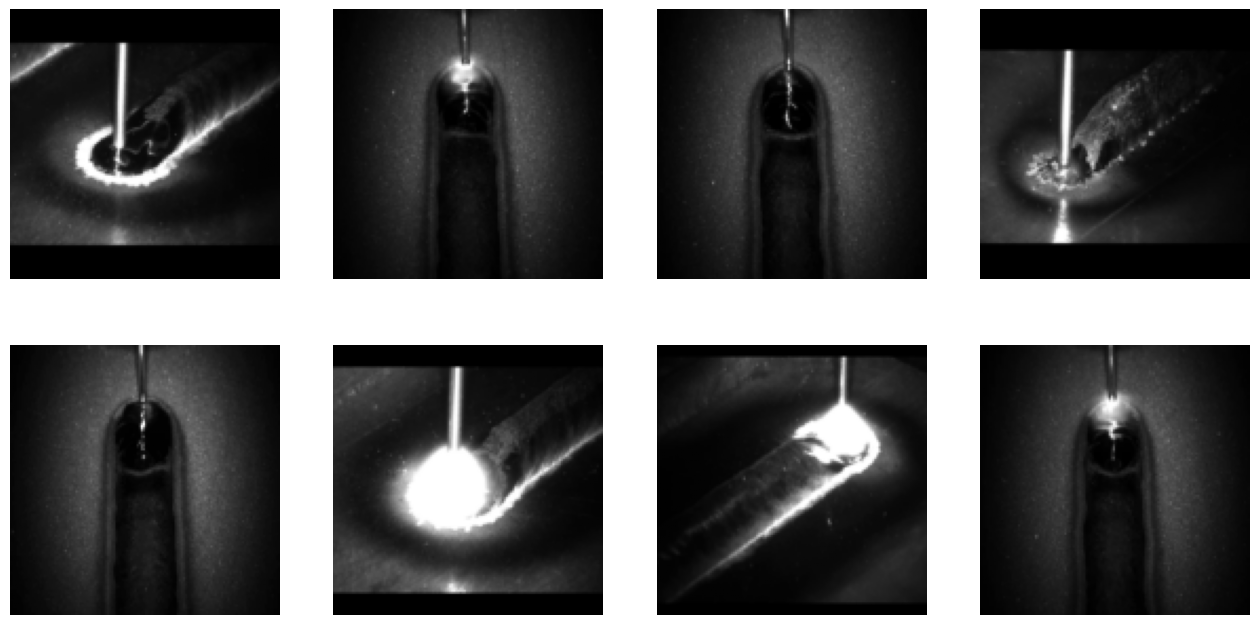

In [9]:
transform = v2.Compose([
    v2.Resize((128, 128)),
    # v2.ColorJitter(contrast=(2.0, 2.0)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.RandomRotation(45),
    # v2.RandomPerspective(),
])

dataset = Kantec2509Dataset(transform=transform)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False, persistent_workers=False, prefetch_factor=None)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_dataloader))
images = batch

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, img in enumerate(images[:8]):
    axes[i].imshow(img.permute(1, 2, 0), cmap="gray")
    axes[i].axis("off")

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.train()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, amsgrad=False)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=50,
    num_training_steps=500,
)
reconstruction_criterion = nn.MSELoss()

In [11]:
def save_checkpoint(model, optimizer, epoch, total_loss, filename="vqvcae_checkpoint.pth"):
    """Saves the current training state."""
    
    # Optional: Create the directory if it doesn't exist
    # os.makedirs("checkpoints", exist_ok=True) 
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': total_loss,
    }
    # Save the dictionary to a file
    torch.save(checkpoint, filename)
    print(f"Checkpoint saved to {filename} at Epoch {epoch+1}")

In [12]:
def load_checkpoint(model, optimizer, filename="vqvcae_best_model.pth", device='cpu'):
    """Loads a saved checkpoint and returns the starting epoch."""
    
    if not os.path.exists(filename):
        print(f"Checkpoint file {filename} not found. Starting training from epoch 0.")
        return 0
    
    # Load the checkpoint dictionary, mapping tensors to the correct device
    checkpoint = torch.load(filename, map_location=device)
    
    # Load the state dictionaries
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Determine the starting epoch
    start_epoch = checkpoint['epoch'] + 1
    
    print(f"Checkpoint loaded successfully. Resuming training from Epoch {start_epoch}.")
    
    return start_epoch

In [13]:
def validate_epoch(model, val_dataloader, criterion, device):
    """Calculates the average total loss on the validation set."""
    
    model.eval() # Set model to evaluation mode (crucial!)
    total_val_loss = 0.0
    num_batches = 0
    
    # Disable gradient calculations during validation
    with torch.no_grad():
        for data in val_dataloader:
            data = data.to(device)
            
            x_recon, vq_loss, _ = model(data)
            
            recon_loss = criterion(x_recon, data)
            total_loss = recon_loss + vq_loss
            
            total_val_loss += total_loss.item()
            num_batches += 1
            
    # Calculate average loss over the validation set
    avg_val_loss = total_val_loss / num_batches
    print(f'\n--- Validation Complete --- Avg. Validation Loss: {avg_val_loss:.4f}')
    
    return avg_val_loss

In [14]:
def train_vqvae_final(model, train_dataloader, val_dataloader, optimizer, num_epochs, criterion, device, start_epoch=0, checkpoint_path="vqvcae_best_model.pth"):
    
    print(f"Starting VQVCAE Training on device: {device}")
    
    # Initialize best_val_loss from a very high number
    best_val_loss = float('inf') 
    
    for epoch in range(start_epoch, start_epoch + num_epochs):
        model.train() # Set to training mode at the start of the epoch
        avg_train_loss = 0.0
        
        for i, data in enumerate(train_dataloader): 
            
            # Training steps (Forward/Backward Pass)
            data = data.to(device)
            x_recon, vq_loss, _ = model(data)
            recon_loss = criterion(x_recon, data)
            total_loss = recon_loss + vq_loss
            
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            avg_train_loss += total_loss.item()
            
            # --- Logging ---
            if (i + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{start_epoch + num_epochs}], '
                      f'Step [{i+1}/{len(train_dataloader)}], '
                      f'Total Loss: {total_loss.item():.4f}, '
                      f'Recon Loss: {recon_loss.item():.4f}, '
                      f'VQ Loss: {vq_loss.item():.4f}')
                
        # -------------------------------------------------------------
        # End of Epoch: Run Validation
        # -------------------------------------------------------------
        current_val_loss = validate_epoch(model, val_dataloader, criterion, device)
        
        # Save Checkpoint Logic: Save only if validation loss improves
        if current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            # Call your separate save_checkpoint function
            save_checkpoint(model, optimizer, epoch, current_val_loss, checkpoint_path)
            print(f"✅ Saved Best Model with Val Loss: {best_val_loss:.4f}")
            
        scheduler.step()
            
    print("Training finished. 🎉")

In [15]:
def test_model(model, test_dataloader, criterion, device, checkpoint_path="vqvcae_best_model.pth"):
    """
    Loads the best saved model and evaluates performance on the test set.
    """
    # Load the best model weights first (optional, but highly recommended)
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded best model saved at epoch {checkpoint['epoch']+1}.")
    except Exception as e:
        print(f"Warning: Could not load checkpoint from {checkpoint_path}. Testing current model state.")
    
    model.eval() # Set to evaluation mode
    total_test_loss = 0.0
    num_batches = 0
    
    # Store individual image errors or latent codes if you plan to do anomaly detection
    # all_anomaly_scores = []
    
    with torch.no_grad():
        for data in test_dataloader:
            data = data.to(device)
            
            x_recon, vq_loss, _ = model(data)
            
            recon_loss = criterion(x_recon, data)
            total_loss = recon_loss + vq_loss
            
            total_test_loss += total_loss.item()
            num_batches += 1
            
            # Example: Calculate anomaly scores here if desired (see previous step)
            # anomaly_scores = torch.sum(torch.square(x_recon - data), dim=[1, 2, 3]).cpu().numpy()
            # all_anomaly_scores.extend(anomaly_scores)

    avg_test_loss = total_test_loss / num_batches
    print(f'\n==================================================')
    print(f'FINAL TEST RESULT: Avg. Test Loss: {avg_test_loss:.4f}')
    print(f'==================================================')
    
    return avg_test_loss # , all_anomaly_scores

In [16]:
# Initialize start_epoch and best_val_loss
start_epoch, best_val_loss = 0, float('inf')

num_epochs = 500

CHECKPOINT_PATH = "vqvcae_best_model.pth"

# Load existing checkpoint if it exists
try:
    start_epoch = load_checkpoint(model, optimizer, CHECKPOINT_PATH, device)
except Exception as e:
    print(f"Error loading checkpoint: {e}. Starting fresh.")
    start_epoch, best_val_loss = 0, float('inf')


# --- 4. EXECUTION: Training and Validation ---
print("\n" + "="*50)
print("STARTING/RESUMING TRAINING")
print("="*50)

# Pass all necessary objects to the training function
train_vqvae_final(
    model=model, 
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader,
    optimizer=optimizer, 
    num_epochs=num_epochs, 
    criterion=reconstruction_criterion, 
    device=device, 
    start_epoch=start_epoch,
    checkpoint_path=CHECKPOINT_PATH
)


# --- 5. EXECUTION: Final Testing ---
print("\n" + "="*50)
print("RUNNING FINAL TEST EVALUATION")
print("="*50)

# The test function will load the best model saved during training
final_test_loss = test_model(
    model=model, 
    test_dataloader=test_dataloader, 
    criterion=reconstruction_criterion, 
    device=device,
    checkpoint_path=CHECKPOINT_PATH
)

Checkpoint file vqvcae_best_model.pth not found. Starting training from epoch 0.

STARTING/RESUMING TRAINING
Starting VQVCAE Training on device: cuda
Epoch [1/500], Step [10/50], Total Loss: 2.4266, Recon Loss: 1.2075, VQ Loss: 1.2191
Epoch [1/500], Step [20/50], Total Loss: 2.4284, Recon Loss: 1.2089, VQ Loss: 1.2195
Epoch [1/500], Step [30/50], Total Loss: 2.4264, Recon Loss: 1.2070, VQ Loss: 1.2194
Epoch [1/500], Step [40/50], Total Loss: 2.4283, Recon Loss: 1.2090, VQ Loss: 1.2193
Epoch [1/500], Step [50/50], Total Loss: 2.4233, Recon Loss: 1.2040, VQ Loss: 1.2193

--- Validation Complete --- Avg. Validation Loss: 2.4267
Checkpoint saved to vqvcae_best_model.pth at Epoch 1
✅ Saved Best Model with Val Loss: 2.4267
Epoch [2/500], Step [10/50], Total Loss: 2.4181, Recon Loss: 1.1984, VQ Loss: 1.2196
Epoch [2/500], Step [20/50], Total Loss: 2.4017, Recon Loss: 1.1823, VQ Loss: 1.2195
Epoch [2/500], Step [30/50], Total Loss: 2.3969, Recon Loss: 1.1766, VQ Loss: 1.2203
Epoch [2/500], Ste

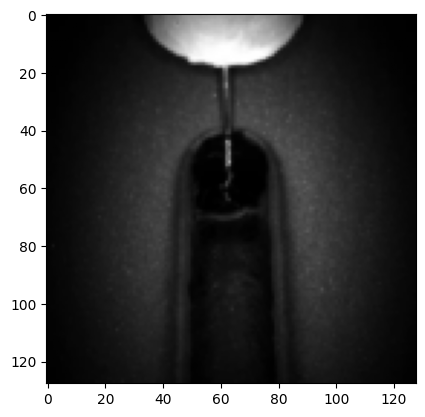

In [17]:
model.eval()
from torchvision.transforms import v2

# Use the same transforms as training:
transform = v2.Compose([
    v2.Grayscale(num_output_channels=1),
    v2.Resize((128, 128)),
    # v2.ColorJitter(contrast=(2.0, 2.0)), # If used during training
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

# Assume 'pil_image' is your single input image (e.g., loaded via PIL.Image.open)
pil_image = Image.open("test.jpg")

# 1. Apply the transformation
transformed_image = transform(pil_image) # Shape: [1, 128, 128] (C, H, W)

# 2. Add the Batch Dimension (B=1)
# The model expects a 4D tensor (Batch, Channels, Height, Width)
input_tensor = transformed_image.unsqueeze(0) # Shape: [1, 1, 128, 128]

# 3. Move the tensor to the correct device
input_tensor = input_tensor.to(device)

plt.imshow(transformed_image.permute(1, 2, 0).numpy().squeeze(), cmap="gray")

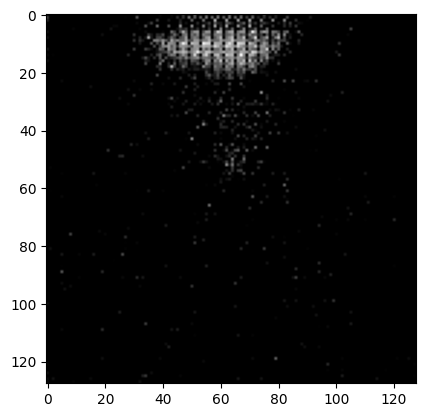

In [18]:
with torch.no_grad():
    # Run the single 4D tensor through the model
    reconstructed_tensor, vq_loss, indices = model(input_tensor)

# The output tensor 'reconstructed_tensor' will have the shape [1, 1, 128, 128]

# --- Post-Processing the Output ---

# 1. Remove the Batch Dimension
reconstructed_image = reconstructed_tensor.squeeze(0) # Shape: [1, 128, 128]

# 2. Move back to CPU (required for visualization/saving)
reconstructed_image = reconstructed_image.cpu()

# 3. Convert to NumPy Array (optional, for visualization tools like matplotlib)
# This removes the channel dimension for grayscale (1, 128, 128) -> (128, 128)
import numpy as np
output_for_display = reconstructed_image.permute(1, 2, 0).numpy().squeeze() 

# You can now display the original image and the reconstructed image:
plt.imshow(output_for_display, cmap='gray')

Total Anomaly Score for Image: 523.5878


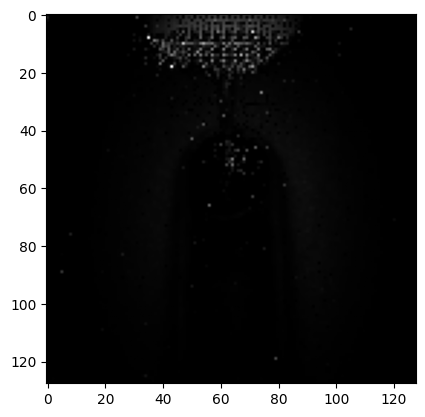

In [19]:
recon_image = reconstructed_image.numpy().squeeze()
original_image = transformed_image.numpy().squeeze()

error_map = np.square(original_image - recon_image) 

# --- 3. Calculate Overall Anomaly Score (Optional) ---

# The final anomaly score for the entire image is usually the sum or mean of the error map
anomaly_score = np.sum(error_map) # or np.mean(error_map)
print(f"Total Anomaly Score for Image: {anomaly_score:.4f}")

plt.imshow(error_map, cmap='gray')